# Identifying center of the image 

In [1]:
# import packages
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import math
import cv2

In [2]:
# loding images and displaying
image_save_dir = r'C:\Users\mj.j\OneDrive - PBA Systems Pte. Ltd\GitHub\Github\2024_06_19_17_26_55\1.png'

In [3]:
image = cv2.imread(image_save_dir)
if image is None:
    print("Error: Could not open or find the image.")
else:
    # Display the image in a window
    cv2.imshow('Loaded Image', image)
    cv2.waitKey(0)  # Wait for a key 'q' press to close the window
    cv2.destroyAllWindows()


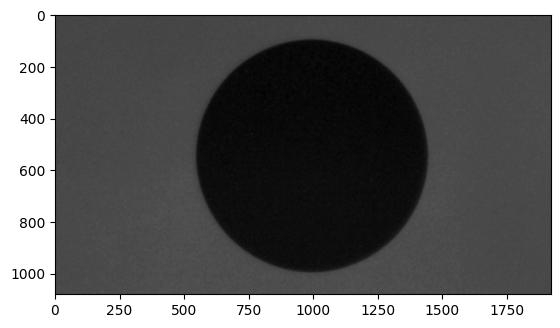

In [4]:
image = cv2.imread(image_save_dir)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_image,cmap='gray')



(1080, 1920) 4.590654385427377
[[[661.5 883.5  35.7]
  [468.5 353.5  25.2]]]


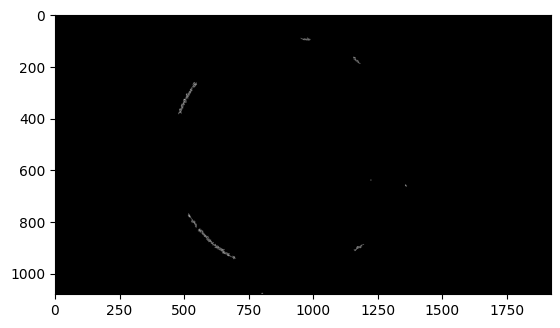

In [110]:
# Method 01

image2 = cv2.imread(image_save_dir, cv2.IMREAD_GRAYSCALE)
laplacian = cv2.Laplacian(image2,cv2.CV_64F).var()
print(image2.shape, laplacian)

edges2 = cv2.Canny(image2,12,100)


# Apply Hough Circle Transform
circles = cv2.HoughCircles(edges2, cv2.HOUGH_GRADIENT, dp=1, minDist=100,
                           param1=1, param2=15)

print(circles)



plt.imshow(edges2,cmap='gray')
plt.savefig('edges2.png')

In [4]:
image = cv2.imread(image_save_dir)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

thresh = cv2.threshold(gray_image, 30, 255, cv2.THRESH_BINARY_INV)[1]

cv2.imshow('Thresholded Image', thresh)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Method 2

In [5]:
# Method 02

def cercle_center_2(image_save_dir,name):

    image = cv2.imread(image_save_dir)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur to reduce noise
    blur = cv2.GaussianBlur(gray_image, (5, 5), 0)

    # Apply a binary threshold to get a binary image
    _, binary = cv2.threshold(blur, 10, 255, cv2.THRESH_BINARY_INV)

    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Loop through contours to find the largest circle
    for contour in contours:
        # Get the moments to calculate the center
        M = cv2.moments(contour)
        if M['m00'] > 600000:
            center_x = int(M['m10'] / M['m00'])
            center_y = int(M['m01'] / M['m00'])
        else:
            center_x, center_y = None, None

    
    if center_x != None and  center_y != None:
        # Draw the center of the circle
        cv2.circle(image, (center_x, center_y), 1, (0, 255, 0), -1)
        print("method 2", M['m00'],center_x, center_y)
        # Optionally, draw the contour
        cv2.drawContours(image, [contour], -1, (0, 255, 0), 1)

        image_center_x = 960
        image_center_y = 540
        line_length = 20
        color_g = (0, 255, 0)  # Green color in BGR
        color_r = (0, 0, 255)
        thickness = 1
        # Draw the horizontal line
        cv2.line(image, (image_center_x - line_length, image_center_y), (image_center_x + line_length, image_center_y), color_r, thickness)
        # Draw the vertical line
        cv2.line(image, (image_center_x, image_center_y - line_length), (image_center_x, image_center_y + line_length), color_r, thickness)


        offset_y  = (image_center_y - center_y) * 0.0005 # Y increase from top to bottom, but cartician does not
        offset_x  = (center_x - image_center_x) * 0.0005 # X increase left to right 

        # Define the text to be added
        text = r'Ofset from the center = ' + str(offset_x) +'mm' + ',' + str(offset_y)+'mm'

        # Define the position where the text will be added (bottom-left corner of the text string)
        position = (50, 50)  # (x, y)

        # Define the font, scale, color, and thickness of the text
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1
        color = (0, 255, 0)  # Green color in BGR
        thickness = 1

        # Add the text to the image
        cv2.putText(image, text, position, font, font_scale, color, thickness)

        # Save the image with the text
        cv2.imwrite(str(name)+'.jpg', image)

    else:
        print("image center not recongized ")

    return  offset_x,offset_y

# Display the result
#plt.imshow(image,cmap='gray')
#plt.savefig('center.png')

#cv2.imshow('Detected Circle', image)
#cv2.waitKey(0)
#cv2.destroyAllWindows()


# Method 3

In [6]:
# method 3

def cercle_center_3(image_save_dir,name):

    # Load the image
    image = cv2.imread(image_save_dir)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply a binary threshold to get a binary image
    #_, binary = cv2.threshold(gray, 2, 255, cv2.THRESH_BINARY_INV)

    # Apply Gaussian blur to reduce noise
    #blur = cv2.GaussianBlur(gray, (9, 9), 0)
    #plt.imshow(blur)

    # Apply Hough Circle Transform
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1, minDist=100, param1=50, param2=15, minRadius=440, maxRadius=460)

    # Ensure circles were found
    if circles is not None:
        # Convert the (x, y) coordinates and radius of the circles to integers
        circles = np.round(circles[0, :]).astype("int")

        # Initialize variables to store largest circle and its radius
        largest_circle = None
        largest_radius = 0

        # Loop over all detected circles
        for (x, y, r) in circles:
            # Check if current circle has larger radius than previous largest
            if r > largest_radius:
                largest_radius = r
                largest_circle = (x, y)

        # Extract center of the largest circle
        if largest_circle is not None:
            largest_center = largest_circle[0], largest_circle[1]
            #print("Center of largest circle:", largest_center)
        else:
            print("No circles found or no circles have radius greater than 0.")
    else:
        print("No circles found.")

    # Draw image crss hair, detected circles on the original image 
    if circles is not None:
        center_x = 960
        center_y = 540
        line_length = 20
        color_g = (0, 255, 0)  # Green color in BGR
        color_r = (0, 0, 255)
        thickness = 1

        # Draw the horizontal line
        cv2.line(image, (center_x - line_length, center_y), (center_x + line_length, center_y), color_r, thickness)

        # Draw the vertical line
        cv2.line(image, (center_x, center_y - line_length), (center_x, center_y + line_length), color_r, thickness)


        for (x, y, r) in circles:
            # Draw circle outline
            cv2.circle(image, (x, y), r, color_g, thickness)
            # Draw center
            cv2.circle(image, (x, y), 2, color_g, thickness)


    offset_y  = (largest_circle[1] - 540) * 0.0005
    offset_x  = (largest_circle[0] - 960) * 0.0005

    # Define the text to be added
    text = r'Ofset from the center = ' + str(offset_x) +'mm' + ',' + str(offset_y)+'mm'

    # Define the position where the text will be added (bottom-left corner of the text string)
    position = (50, 50)  # (x, y)

    # Define the font, scale, color, and thickness of the text
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1
    color = (0, 255, 0)  # Green color in BGR
    thickness = 1

    # Add the text to the image
    cv2.putText(image, text, position, font, font_scale, color, thickness)

    # Save the image with the text
    cv2.imwrite(str(name)+'.jpg', image)

    # Display the image
    #cv2.imshow('Image with Text', image)
    #cv2.waitKey(0)
    #cv2.destroyAllWindows()

    return offset_x,offset_y


# Function call

In [13]:
# cannot create dir using index can only run the fix value
for index in range(1,17,1):
    image_save_dir = r'C:\Users\mj.j\OneDrive - PBA Systems Pte. Ltd\GitHub\Github\2024_06_19_17_26_55\1.png'
    offset_x,offset_y =  cercle_center_2(image_save_dir,index)
    print(offset_x,offset_y)

method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025
method 2 619681.0 991 545
0.0155 -0.0025


In [4]:
import os

def print_directory_structure(root_dir, stop_dir, indent_level=0):
    if indent_level > 3:  # Limit depth to 3 levels (C:/, C:/Users/, C:/Users/YourUsername/, C:/Users/YourUsername/Documents/)
        return
    
    try:
        for root, dirs, files in os.walk(root_dir):
            # Indentation based on the level of directory
            indent = ' ' * indent_level
            print(f"{indent}{os.path.basename(root)}/")
            
            if os.path.abspath(root) == os.path.abspath(stop_dir):
                return
            
            # Print subdirectories
            for dir in dirs:
                print(f"{indent}  {dir}/")
            
            # Print files
            for file in files:
                print(f"{indent}  {file}")
            
            # Increase indent level for subdirectories
            for dir in dirs:
                print_directory_structure(os.path.join(root, dir), stop_dir, indent_level + 2)
            break  # Ensure it doesn't recursively print all directories in one go
    except PermissionError:
        print(f"Permission Denied: {root_dir}")
        return

# Specify the root directory and stop directory
root_directory = "C:/Users"  # Change this to the root directory
stop_directory = "C:/Users/YourUsername/Documents"  # Change this to the specific directory to stop

print_directory_structure(root_directory, stop_directory)

Users/
  All Users/
  Default/
  Default User/
  mj.j/
  PBA/
  Public/
  desktop.ini
  All Users/
    ACS Motion Control/
    Adobe/
    AMETEK, Inc/
    AnyDesk/
    Application Data/
    boost_interprocess/
    BraveSoftware/
    Broadcom/
    Brother/
    CodeMeter/
    Dell/
    Desktop/
    Documents/
    Dolby/
    Elmo Motion Control/
    filezilla-server/
    FLEXnet/
    Goodix/
    Intel/
    IObit/
    Isolated Storage/
    iTop/
    Lenovo/
    Microsoft/
    Microsoft OneDrive/
    Microsoft Visual Studio/
    obs-studio/
    obs-studio-hook/
    Oracle/
    Package Cache/
    Packages/
    PBA/
    PDFsam Basic/
    PDFsam Enhanced 7/
    Pico Technology/
    PLUG/
    ProductData/
    ProductData3/
    RealVNC-Service/
    regid.1991-06.com.microsoft/
    Servotronix/
    SoftwareDistribution/
    ssh/
    Start Menu/
    Temp/
    Templates/
    USOPrivate/
    USOShared/
    Waves/
    Windows App Certification Kit/
    WindowsHolographicDevices/
    cm-lock
    ntuse